# AQI Data Warehouse — Exploratory Analysis

Individual analysis notebook, based on the `fact_air_quality` / `dim_city` / `dim_time`
star schema loaded in our Neon Postgres warehouse.

**Goals of this notebook:**
1. Connect to the warehouse and load the data into a single analysis-ready DataFrame
2. Overview of coverage (rows per city, date range, missing values)
3. AQI comparison across the 5 cities
4. Time trends (daily/weekly evolution, pollution peaks)
5. Correlations between pollutants
6. Weekday vs weekend and hour-of-day patterns

1. Setup & Connection

We load environment variables and open a single SQLAlchemy engine — reused by every query below instead of reconnecting each time.

In [ ]:
#setup
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv()

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

DATABASE_URL = os.getenv("DATABASE_URL")

#print(f"✅ DATABASE_URL found: {DATABASE_URL[:30]}..." if DATABASE_URL else "❌ DATABASE_URL not found! Create a .env file with DATABASE_URL=...")
if not DATABASE_URL:
    raise ValueError("❌ Nooooooooooooo DATABASE_URL not found! Create a .env file with DATABASE_URL=...")

engine = create_engine(DATABASE_URL)
print("Yessssss the data_warehouse is connected successfully!" if engine else "Connection object not created.")

Yessssss the data_warehouse is connected successfully!


2. Loading the data

We join the fact table with both dimensions into one flat DataFrame — the most convenient shape for exploratory analysis in pandas.

In [11]:
query = """
SELECT
    c.city_name,
    c.country,
    c.latitude,
    c.longitude,
    t.timestamp_utc,
    t.date,
    t.hour,
    t.day_of_week,
    t.day_name,
    t.is_weekend,
    f.aqi,
    f.co, f.no, f.no2, f.o3, f.so2, f.pm2_5, f.pm10, f.nh3
FROM fact_air_quality f
JOIN dim_city c ON c.city_key = f.city_key
JOIN dim_time t ON t.time_key = f.time_key
ORDER BY c.city_name, t.timestamp_utc
"""

df = pd.read_sql(query, engine)
df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
print(f"{len(df):,} rows loaded, {df['city_name'].nunique()} cities")
df

10,368 rows loaded, 5 cities


,city_name,country,latitude,longitude,timestamp_utc,date,hour,day_of_week,day_name,is_weekend,aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,Antananarivo,MG,-18.8792,47.5079,2026-04-26 12:00:00+00:00,2026-04-26,12,6,Dimanche,True,1,62.86,0.03,0.10,43.89,0.12,0.87,1.58,0.41
1,Antananarivo,MG,-18.8792,47.5079,2026-04-26 13:00:00+00:00,2026-04-26,13,6,Dimanche,True,1,67.81,0.05,0.19,41.59,0.14,1.07,2.00,0.64
2,Antananarivo,MG,-18.8792,47.5079,2026-04-26 14:00:00+00:00,2026-04-26,14,6,Dimanche,True,1,76.20,0.05,0.41,37.69,0.16,1.36,2.67,0.92
3,Antananarivo,MG,-18.8792,47.5079,2026-04-26 15:00:00+00:00,2026-04-26,15,6,Dimanche,True,1,85.01,0.01,0.73,34.26,0.18,1.67,3.34,1.11
4,Antananarivo,MG,-18.8792,47.5079,2026-04-26 16:00:00+00:00,2026-04-26,16,6,Dimanche,True,1,94.56,0.00,0.96,30.59,0.20,2.05,4.23,1.29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10363,Paris,FR,48.8566,2.3522,2026-07-25 07:00:00+00:00,2026-07-25,7,5,Samedi,True,1,125.21,0.51,4.91,59.76,0.75,5.45,7.40,5.70
10364,Paris,FR,48.8566,2.3522,2026-07-25 08:00:00+00:00,2026-07-25,8,5,Samedi,True,2,125.84,0.94,4.76,60.96,0.82,5.73,7.76,5.64
10365,Paris,FR,48.8566,2.3522,2026-07-25 09:00:00+00:00,2026-07-25,9,5,Samedi,True,2,125.60,1.04,4.33,67.10,0.93,6.13,8.25,5.43
10366,Paris,FR,48.8566,2.3522,2026-07-25 10:00:00+00:00,2026-07-25,10,5,Samedi,True,2,115.95,0.32,1.80,95.92,0.73,5.54,7.19,3.34


3. Data quality

Before trusting any chart, we check what's actually in the warehouse: missing values, duplicate (city, timestamp) pairs, gaps in the hourly cadence, and out-of-range pollutant values.

In [14]:
print("=" * 60)
print("DATA QUALITY")
print("=" * 60)

print(f"\nDate range : {df['timestamp_utc'].min()} → {df['timestamp_utc'].max()}")
print(f"Cities : {df['city_name'].nunique()} — {list(df['city_name'].unique())}")
print(f"Total rows : {len(df):,}")

# Missing values per column
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing": missing, "pct": missing_pct})
print("\nMissing values :\n", missing_df[missing_df["missing"] > 0])

# Duplicate city/timestamp pairs
dupes = df.duplicated(subset=["city_name", "timestamp_utc"]).sum()
print(f"\nDuplicates (city, timestamp) : {dupes}")

# Temporal continuity per city (gaps in the hourly pipeline)
def check_gaps(g):
    g = g.sort_values("timestamp_utc")
    diffs = g["timestamp_utc"].diff().dropna()
    expected = pd.Timedelta(hours=1)
    gaps = (diffs > expected).sum()
    max_gap = diffs.max()
    return pd.Series({"n_points": len(g), "gaps": gaps, "max_gap": max_gap})

gaps_report = df.groupby("city_name").apply(check_gaps)
print("\nHourly continuity per city :\n", gaps_report)

# Outlier values (negative AQI, negative pollutants, extreme outliers)
pollutant_cols = ["aqi", "co", "no", "no2", "o3", "so2", "pm2_5", "pm10", "nh3"]
print("\nNegative values per column :")
print((df[pollutant_cols] < 0).sum())

print("\nDescriptive statistics :")
print(df[pollutant_cols].describe().T)

DATA QUALITY

Date range : 2026-04-26 12:00:00+00:00 → 2026-07-25 11:00:00+00:00
Cities : 5 — ['Antananarivo', 'Beijing', 'Nairobi', 'New Delhi', 'Paris']
Total rows : 10,368

Missing values :
 Empty DataFrame
Columns: [missing, pct]
Index: []

Duplicates (city, timestamp) : 0

Hourly continuity per city :
               n_points  gaps         max_gap
city_name                                   
Antananarivo      2088     3 1 days 01:00:00
Beijing           2064     4 1 days 01:00:00
Nairobi           2088     3 1 days 01:00:00
New Delhi         2040     5 1 days 01:00:00
Paris             2088     3 1 days 01:00:00

Negative values per column :
aqi      0
co       0
no       0
no2      0
o3       0
so2      0
pm2_5    0
pm10     0
nh3      0
dtype: int64

Descriptive statistics :
         count        mean         std    min      25%      50%       75%  \
aqi    10368.0    2.215085    1.319741   1.00   1.0000    2.000    3.0000   
co     10368.0  191.143314  134.122297  61.22  96.0575

/tmp/ipykernel_12672/1108951107.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gaps_report = df.groupby("city_name").apply(check_gaps)


4. City comparison

We compare AQI distributions and average pollutant levels city by city, to see which locations are consistently more polluted.

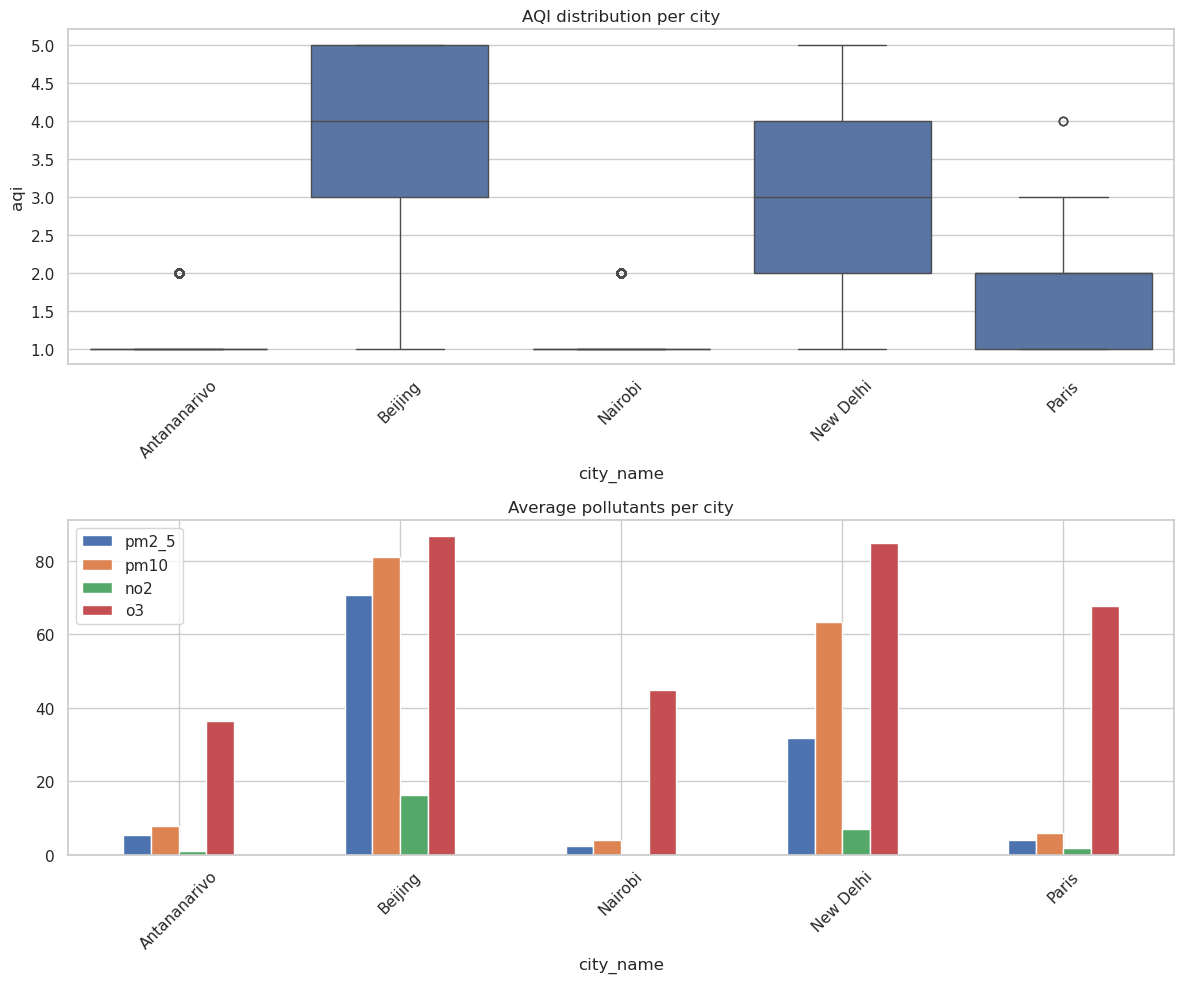

                  mean  median  max
city_name                          
Beijing       4.070736     4.0    5
New Delhi     3.009804     3.0    5
Paris         1.751916     2.0    4
Antananarivo  1.183429     1.0    2
Nairobi       1.099138     1.0    2


In [15]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# AQI distribution per city
sns.boxplot(data=df, x="city_name", y="aqi", ax=axes[0])
axes[0].set_title("AQI distribution per city")
axes[0].tick_params(axis="x", rotation=45)

# Average main pollutants per city
city_means = df.groupby("city_name")[["pm2_5", "pm10", "no2", "o3"]].mean()
city_means.plot(kind="bar", ax=axes[1])
axes[1].set_title("Average pollutants per city")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# City ranking by average AQI
ranking = df.groupby("city_name")["aqi"].agg(["mean", "median", "max"]).sort_values("mean", ascending=False)
print(ranking)